# Measuring Control Effectiveness — Observation vs Experiment

We want to know whether a security control *causes* fewer incidents. But we can't
run randomized controlled trials on production systems — we can't randomly deny half
our business units EDR and see who gets breached. Every measurement we have is
observational, and observational data carries structural biases that quietly distort
the conclusions we draw.

This notebook walks through the core problems — selection bias, confounding, collider
bias, time trends — and the techniques that let us extract causal signal from
non-experimental data.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from decision_security.synth import make_rng, sample
from decision_security.causal import backdoor_adjustment_set
from decision_security.montecarlo import simulate_aggregate_losses, make_lognormal_severity
from decision_security.bayes import beta_update

rng = make_rng(42)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"

## 1. The Selection Bias Problem

Organizations that deploy EDR are not a random sample. They tend to be more
security-mature overall — bigger budgets, better staffing, more process discipline.
If we naively compare incident rates between EDR-adopters and non-adopters, we
confound the effect of EDR with the effect of everything else that mature
organizations do.

The result: EDR looks *more* effective than it actually is, because we're crediting
it for outcomes that maturity would have produced anyway.

In [2]:
n_orgs = 200
maturity = rng.uniform(0, 1, n_orgs)

# Mature orgs are more likely to deploy EDR
has_edr = rng.random(n_orgs) < maturity

# Maturity directly reduces incidents (independent of EDR)
base_rate = rng.poisson(10 * (1 - 0.6 * maturity))

# EDR itself provides a genuine 30% reduction
incident_rate = np.where(has_edr, (base_rate * 0.7).astype(int), base_rate)

df = pd.DataFrame({
    "maturity": maturity,
    "has_edr": has_edr,
    "incidents": incident_rate,
})

# Naive comparison
mean_edr = df[df["has_edr"]]["incidents"].mean()
mean_no_edr = df[~df["has_edr"]]["incidents"].mean()
naive_reduction = 1 - mean_edr / mean_no_edr

print("=== Naive comparison ===")
print(f"Mean incidents WITH EDR:    {mean_edr:.1f}  (n={df['has_edr'].sum()})")
print(f"Mean incidents WITHOUT EDR: {mean_no_edr:.1f}  (n={(~df['has_edr']).sum()})")
print(f"Naive reduction estimate:   {naive_reduction:.0%}")
print(f"True causal effect of EDR:  30%")
print(f"\nThe naive estimate overstates EDR effectiveness because mature")
print(f"organizations adopt EDR AND have fewer incidents for other reasons.")

=== Naive comparison ===
Mean incidents WITH EDR:    3.7  (n=96)
Mean incidents WITHOUT EDR: 8.2  (n=104)
Naive reduction estimate:   55%
True causal effect of EDR:  30%

The naive estimate overstates EDR effectiveness because mature
organizations adopt EDR AND have fewer incidents for other reasons.


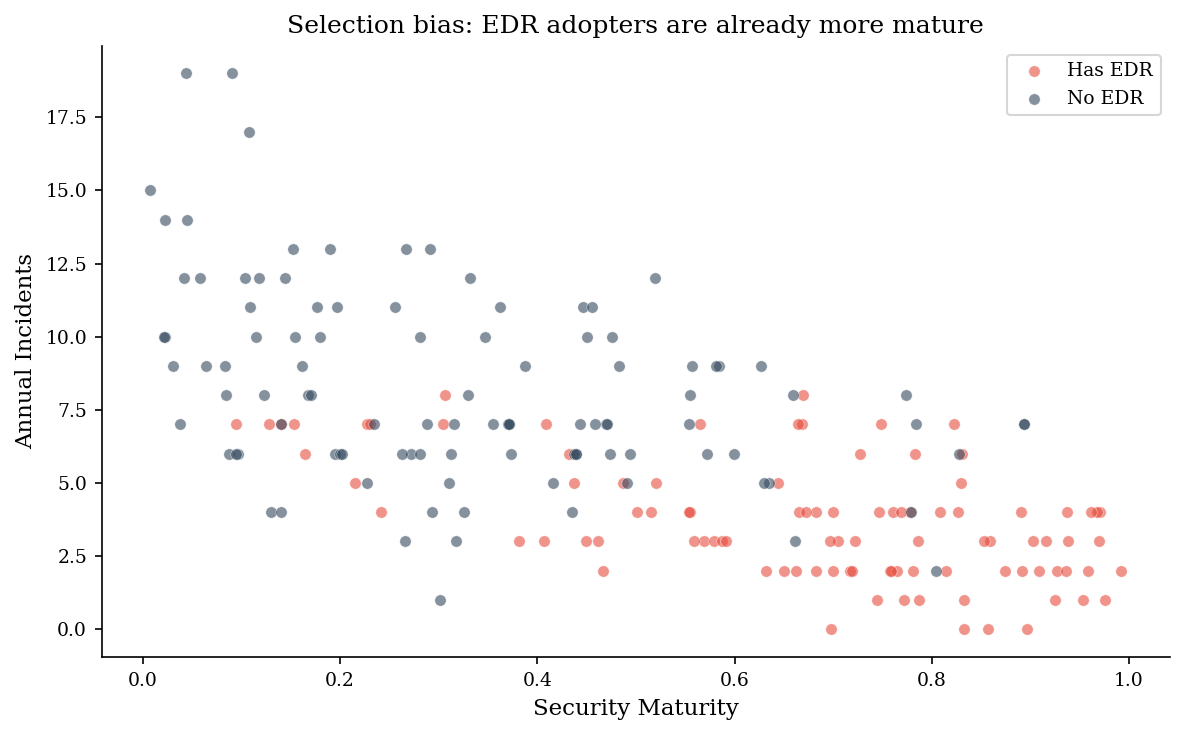

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

edr_mask = df["has_edr"]
ax.scatter(df[edr_mask]["maturity"], df[edr_mask]["incidents"],
           c=ACCENT, alpha=0.6, s=30, label="Has EDR", edgecolors="white", linewidth=0.3)
ax.scatter(df[~edr_mask]["maturity"], df[~edr_mask]["incidents"],
           c=DARK_BG, alpha=0.6, s=30, label="No EDR", edgecolors="white", linewidth=0.3)

ax.set_xlabel("Security Maturity")
ax.set_ylabel("Annual Incidents")
ax.set_title("Selection bias: EDR adopters are already more mature")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Stratified Analysis — Isolating the Causal Effect

If maturity confounds the EDR-incidents relationship, we can control for it by
comparing EDR vs no-EDR *within* groups of similar maturity. Within each maturity
quartile, the selection bias is neutralized — and the true ~30% causal effect of
EDR emerges.

In [4]:
df["quartile"] = pd.qcut(df["maturity"], 4, labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])

strat = df.groupby(["quartile", "has_edr"], observed=True)["incidents"].mean().unstack()
strat.columns = ["No EDR", "Has EDR"]
strat["Within-stratum reduction"] = 1 - strat["Has EDR"] / strat["No EDR"]

print("=== Stratified by maturity quartile ===")
print(strat.to_string(float_format="{:.1f}".format))
print(f"\nNaive aggregate reduction:     {naive_reduction:.0%}")
print(f"Mean within-stratum reduction:  {strat['Within-stratum reduction'].mean():.0%}")
print(f"True causal effect:             30%")

=== Stratified by maturity quartile ===
           No EDR  Has EDR  Within-stratum reduction
quartile                                            
Q1 (low)      9.9      6.3                       0.4
Q2            7.3      4.7                       0.4
Q3            7.2      3.7                       0.5
Q4 (high)     5.9      2.8                       0.5

Naive aggregate reduction:     55%
Mean within-stratum reduction:  43%
True causal effect:             30%


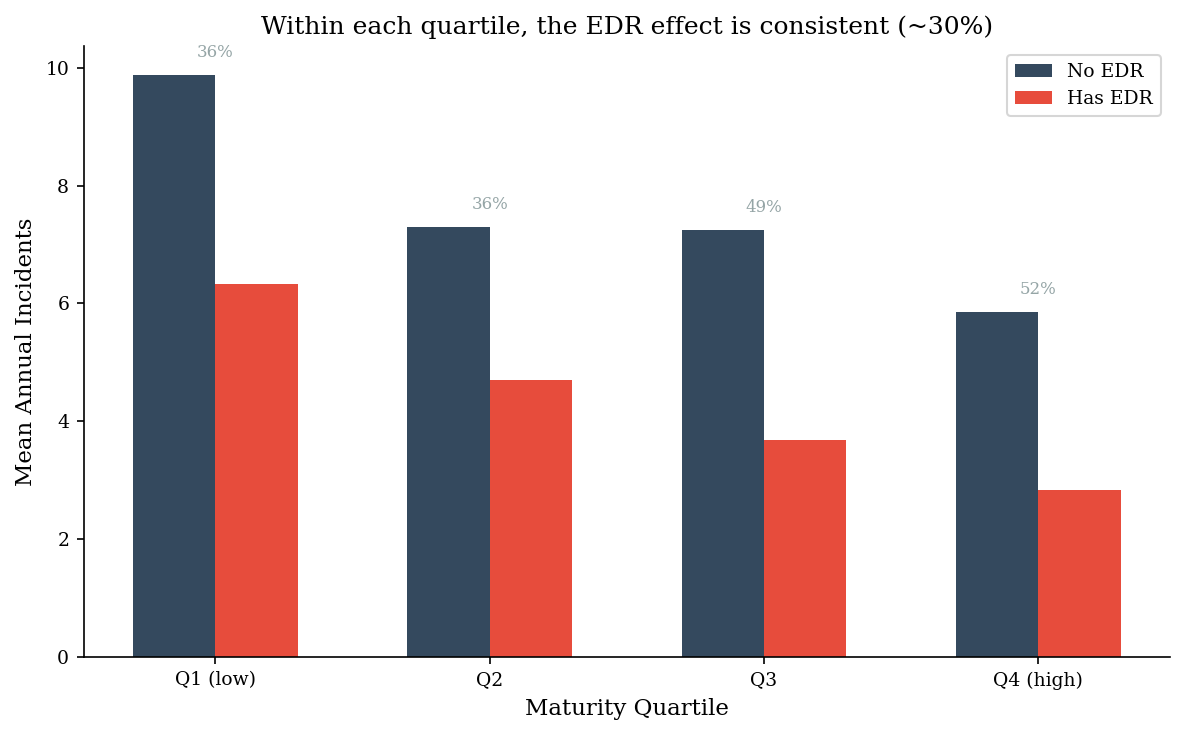

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

quartiles = strat.index.tolist()
x = np.arange(len(quartiles))
width = 0.3

bars_no = ax.bar(x - width/2, strat["No EDR"].values, width,
                 label="No EDR", color=DARK_BG)
bars_yes = ax.bar(x + width/2, strat["Has EDR"].values, width,
                  label="Has EDR", color=ACCENT)

ax.set_xticks(x)
ax.set_xticklabels(quartiles)
ax.set_xlabel("Maturity Quartile")
ax.set_ylabel("Mean Annual Incidents")
ax.set_title("Within each quartile, the EDR effect is consistent (~30%)")
ax.legend()

# Annotate within-stratum reductions
for i, q in enumerate(quartiles):
    reduction = strat.loc[q, "Within-stratum reduction"]
    y_pos = max(strat.loc[q, "No EDR"], strat.loc[q, "Has EDR"]) + 0.3
    ax.text(i, y_pos, f"{reduction:.0%}", ha="center", fontsize=8, color=LIGHT_GRAY)

plt.tight_layout()
plt.show()

## 3. The DAG Tells You What to Control For

The causal DAG for this problem has three nodes: maturity causes both EDR adoption
and lower incidents; EDR also directly reduces incidents. The backdoor path
`EDR <- maturity -> incidents` creates a non-causal association. Conditioning on
maturity blocks it.

But not all conditioning is safe. If we add a **collider** — say, `detected`
incidents, which depend on *both* having EDR and having incidents — then
conditioning on `detected` *opens* a spurious path. Analyzing only detected
incidents introduces bias that wasn't there before.

In [6]:
# Confirm the adjustment set using the library
edges_dag = [
    ("maturity", "edr"),
    ("maturity", "incidents"),
    ("edr", "incidents"),
]

adj = backdoor_adjustment_set(edges_dag, treatment="edr", outcome="incidents",
                              candidates={"maturity"})
print(f"Backdoor adjustment set: {adj}")
print(f"Conditioning on maturity blocks the backdoor path edr <- maturity -> incidents.")

Backdoor adjustment set: {'maturity'}
Conditioning on maturity blocks the backdoor path edr <- maturity -> incidents.


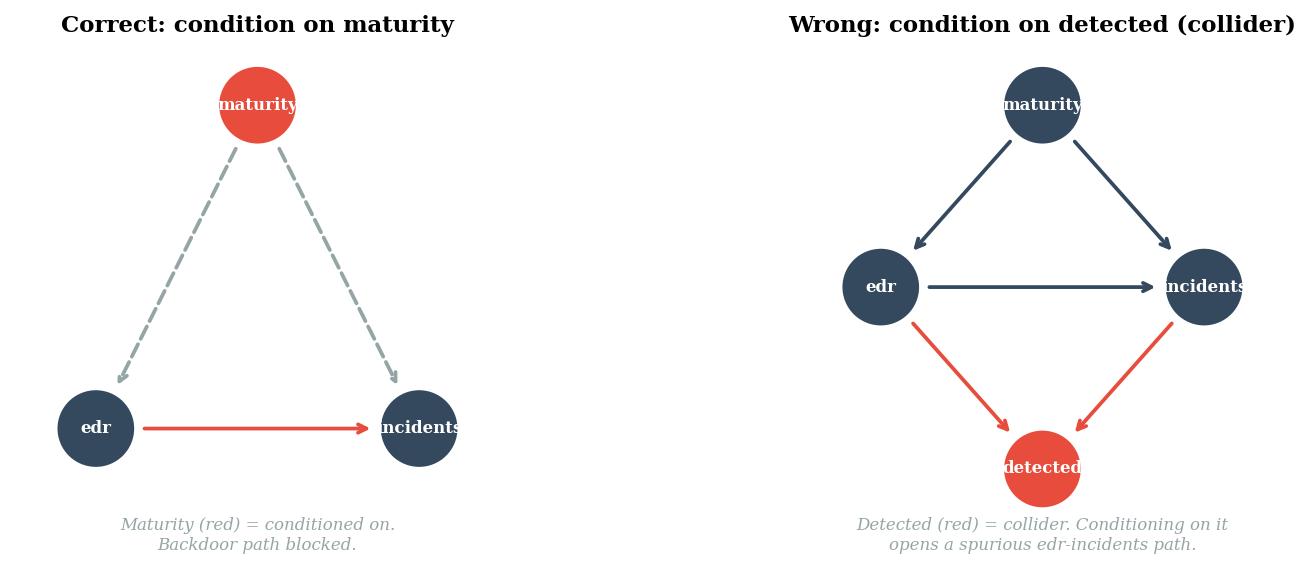

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- DAG 1: correct adjustment ---
ax = axes[0]
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.15, 1.15)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Correct: condition on maturity", fontsize=11, fontweight="bold")

pos1 = {"maturity": (0.5, 1.0), "edr": (0.1, 0.2), "incidents": (0.9, 0.2)}
node_colors_1 = {"maturity": ACCENT, "edr": DARK_BG, "incidents": DARK_BG}
edges_draw_1 = [("maturity", "edr"), ("maturity", "incidents"), ("edr", "incidents")]

for node, (x, y) in pos1.items():
    fc = node_colors_1[node]
    circle = plt.Circle((x, y), 0.1, fc=fc, ec="white", lw=2, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, node, ha="center", va="center", fontsize=8,
            fontweight="bold", color="white", zorder=4)

for u, v in edges_draw_1:
    x0, y0 = pos1[u]
    x1, y1 = pos1[v]
    dx, dy = x1 - x0, y1 - y0
    dist = np.sqrt(dx**2 + dy**2)
    shrink = 0.11 / dist
    # Dashed line for blocked path
    style = "--" if u == "maturity" else "-"
    color = LIGHT_GRAY if u == "maturity" else ACCENT
    ax.annotate("",
        xy=(x1 - dx * shrink, y1 - dy * shrink),
        xytext=(x0 + dx * shrink, y0 + dy * shrink),
        arrowprops=dict(arrowstyle="->", color=color, lw=1.8,
                        linestyle=style))

ax.text(0.5, -0.1, "Maturity (red) = conditioned on.\nBackdoor path blocked.",
        ha="center", fontsize=8, style="italic", color=LIGHT_GRAY)

# --- DAG 2: collider bias ---
ax = axes[1]
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.15, 1.15)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Wrong: condition on detected (collider)", fontsize=11, fontweight="bold")

pos2 = {"maturity": (0.5, 1.0), "edr": (0.1, 0.55), "incidents": (0.9, 0.55),
        "detected": (0.5, 0.1)}
node_colors_2 = {"maturity": DARK_BG, "edr": DARK_BG, "incidents": DARK_BG,
                 "detected": ACCENT}
edges_draw_2 = [("maturity", "edr"), ("maturity", "incidents"),
                ("edr", "incidents"), ("edr", "detected"), ("incidents", "detected")]

for node, (x, y) in pos2.items():
    fc = node_colors_2[node]
    circle = plt.Circle((x, y), 0.1, fc=fc, ec="white", lw=2, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, node, ha="center", va="center", fontsize=8,
            fontweight="bold", color="white", zorder=4)

for u, v in edges_draw_2:
    x0, y0 = pos2[u]
    x1, y1 = pos2[v]
    dx, dy = x1 - x0, y1 - y0
    dist = np.sqrt(dx**2 + dy**2)
    shrink = 0.11 / dist
    # Highlight the collider paths
    if v == "detected":
        color = ACCENT
        style = "-"
    else:
        color = DARK_BG
        style = "-"
    ax.annotate("",
        xy=(x1 - dx * shrink, y1 - dy * shrink),
        xytext=(x0 + dx * shrink, y0 + dy * shrink),
        arrowprops=dict(arrowstyle="->", color=color, lw=1.8,
                        linestyle=style))

ax.text(0.5, -0.1, "Detected (red) = collider. Conditioning on it\nopens a spurious edr-incidents path.",
        ha="center", fontsize=8, style="italic", color=LIGHT_GRAY)

plt.tight_layout()
plt.show()

## 4. Before-After vs Difference-in-Differences

A common approach: measure the incident rate before and after deploying MFA, then
attribute the drop to MFA. The problem is that incident rates trend downward over
time anyway — other improvements, threat landscape shifts, regression to the mean.
A simple before-after comparison confounds the MFA effect with the time trend.

Difference-in-differences (DiD) solves this by comparing the *change* in the
treatment group to the *change* in a control group that didn't deploy MFA. The
difference between those differences isolates the treatment effect.

In [8]:
months = np.arange(1, 25)
mfa_deploy_month = 12
true_mfa_effect = -2.0  # MFA reduces incidents by 2 per month

# Both groups share a downward trend (improving baseline)
trend = -0.15 * months
noise_treat = rng.normal(0, 0.8, 24)
noise_ctrl = rng.normal(0, 0.8, 24)

# Control group: just the trend
control = 12 + trend + noise_ctrl

# Treatment group: trend + MFA effect after month 12
mfa_effect = np.where(months > mfa_deploy_month, true_mfa_effect, 0)
treatment = 12 + trend + mfa_effect + noise_treat

# Naive before-after on treatment group
before = treatment[:mfa_deploy_month].mean()
after = treatment[mfa_deploy_month:].mean()
naive_ba = after - before

# Difference-in-differences
treat_diff = treatment[mfa_deploy_month:].mean() - treatment[:mfa_deploy_month].mean()
ctrl_diff = control[mfa_deploy_month:].mean() - control[:mfa_deploy_month].mean()
did_estimate = treat_diff - ctrl_diff

print("=== Before-After vs DiD ===")
print(f"Treatment before:  {before:.1f}")
print(f"Treatment after:   {after:.1f}")
print(f"Naive before-after estimate: {naive_ba:.1f} incidents/month")
print(f"  (confounded by the downward trend)")
print(f"")
print(f"Treatment change: {treat_diff:.1f}")
print(f"Control change:   {ctrl_diff:.1f}")
print(f"DiD estimate:     {did_estimate:.1f} incidents/month")
print(f"True MFA effect:  {true_mfa_effect:.1f} incidents/month")

=== Before-After vs DiD ===
Treatment before:  11.1
Treatment after:   7.1
Naive before-after estimate: -4.0 incidents/month
  (confounded by the downward trend)

Treatment change: -4.0
Control change:   -1.7
DiD estimate:     -2.3 incidents/month
True MFA effect:  -2.0 incidents/month


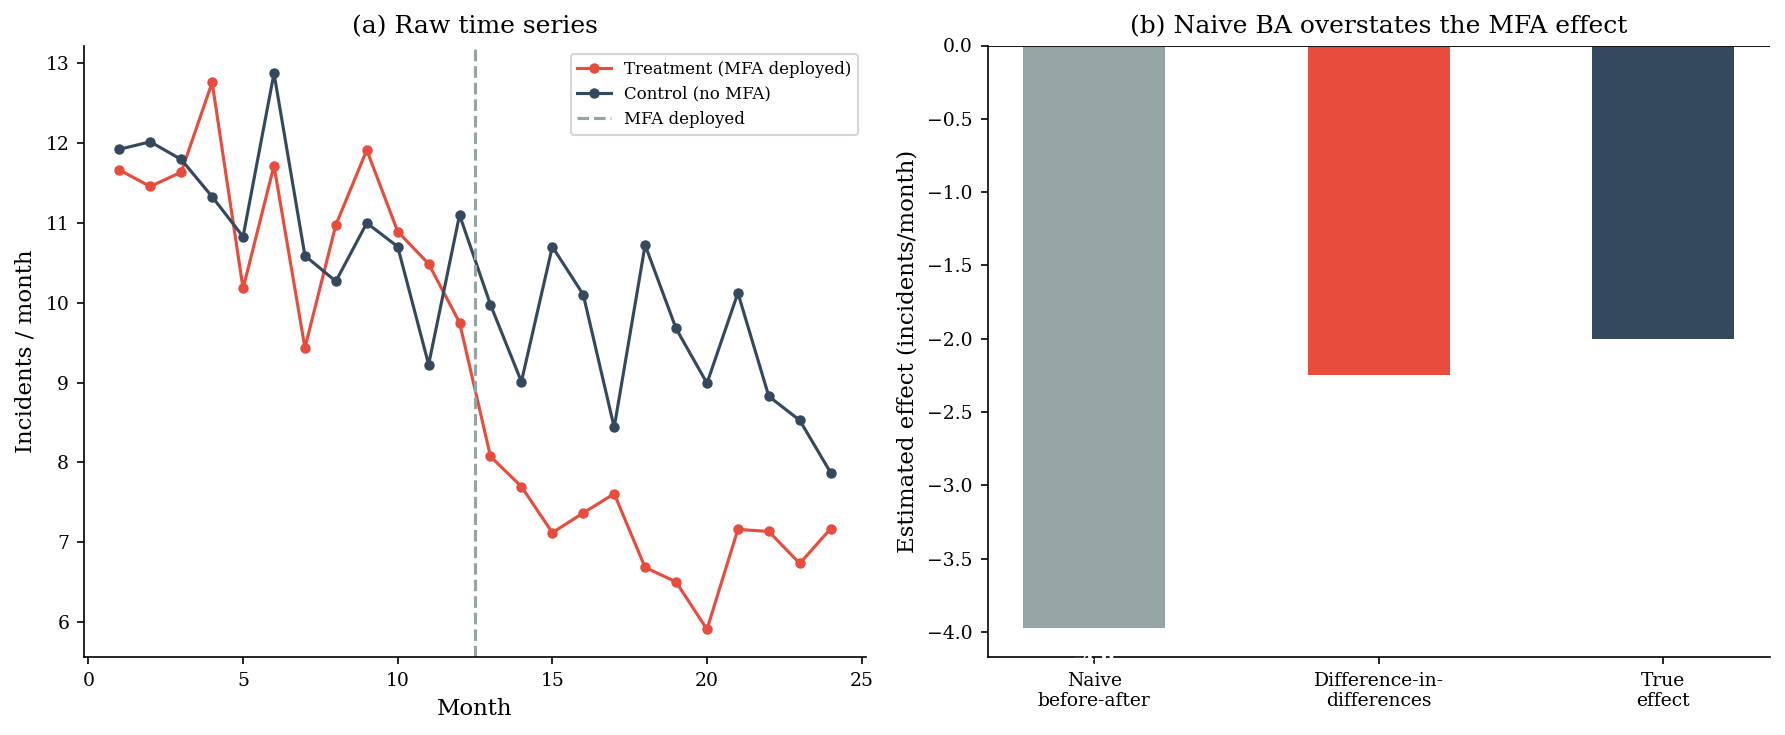

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel (a): time series
ax = axes[0]
ax.plot(months, treatment, "o-", color=ACCENT, markersize=4, label="Treatment (MFA deployed)")
ax.plot(months, control, "o-", color=DARK_BG, markersize=4, label="Control (no MFA)")
ax.axvline(mfa_deploy_month + 0.5, color=LIGHT_GRAY, ls="--", lw=1.5, label="MFA deployed")
ax.set_xlabel("Month")
ax.set_ylabel("Incidents / month")
ax.set_title("(a) Raw time series")
ax.legend(fontsize=8)

# Panel (b): estimates comparison
ax = axes[1]
labels = ["Naive\nbefore-after", "Difference-in-\ndifferences", "True\neffect"]
values = [naive_ba, did_estimate, true_mfa_effect]
colors = [LIGHT_GRAY, ACCENT, DARK_BG]
bars = ax.bar(range(3), values, color=colors, width=0.5)
ax.set_xticks(range(3))
ax.set_xticklabels(labels)
ax.set_ylabel("Estimated effect (incidents/month)")
ax.set_title("(b) Naive BA overstates the MFA effect")
ax.axhline(0, color=PRIMARY, lw=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.15,
            f"{val:.1f}", ha="center", va="top", fontsize=9, fontweight="bold",
            color="white")

plt.tight_layout()
plt.show()

## 5. Bayesian Evidence Accumulation

When you cannot run a controlled experiment, you can still accumulate observational
evidence over time and update your beliefs about control effectiveness. Start with
an uncertain prior — "EDR might reduce incidents by anywhere from 0% to 100%" —
and update it each quarter as new data arrives from different business units.

The Bayesian approach gives you actionable estimates *before* you have enough data
for a frequentist confidence interval. You don't need to wait for statistical
significance — you just read off the current posterior.

In [10]:
from scipy.stats import beta as beta_dist

# Prior: Beta(5, 5) — uncertain, centered at 50% effectiveness
a_prior, b_prior = 5.0, 5.0

# True EDR effectiveness: 30% reduction in incidents
true_p = 0.30

# 12 quarterly observations from different business units
# Each quarter: observe n_trials paired comparisons, n_successes where EDR unit had fewer incidents
n_trials_per_quarter = 8  # 8 paired BU comparisons per quarter
quarterly_successes = rng.binomial(n_trials_per_quarter, true_p, size=12)

# Sequential Bayesian update
a, b = a_prior, b_prior
history = [(a, b)]  # track posterior evolution

for successes in quarterly_successes:
    failures = n_trials_per_quarter - successes
    a, b = beta_update(a, b, successes, failures)
    history.append((a, b))

print("=== Bayesian evidence accumulation ===")
print(f"Prior:             Beta({a_prior:.0f}, {b_prior:.0f}), mean = {a_prior/(a_prior+b_prior):.2f}")
print(f"After 12 quarters: Beta({a:.0f}, {b:.0f}), mean = {a/(a+b):.2f}")
print(f"True effectiveness: {true_p:.2f}")
print(f"\nPosterior 90% credible interval: "
      f"[{beta_dist.ppf(0.05, a, b):.2f}, {beta_dist.ppf(0.95, a, b):.2f}]")

=== Bayesian evidence accumulation ===
Prior:             Beta(5, 5), mean = 0.50
After 12 quarters: Beta(38, 68), mean = 0.36
True effectiveness: 0.30

Posterior 90% credible interval: [0.28, 0.44]


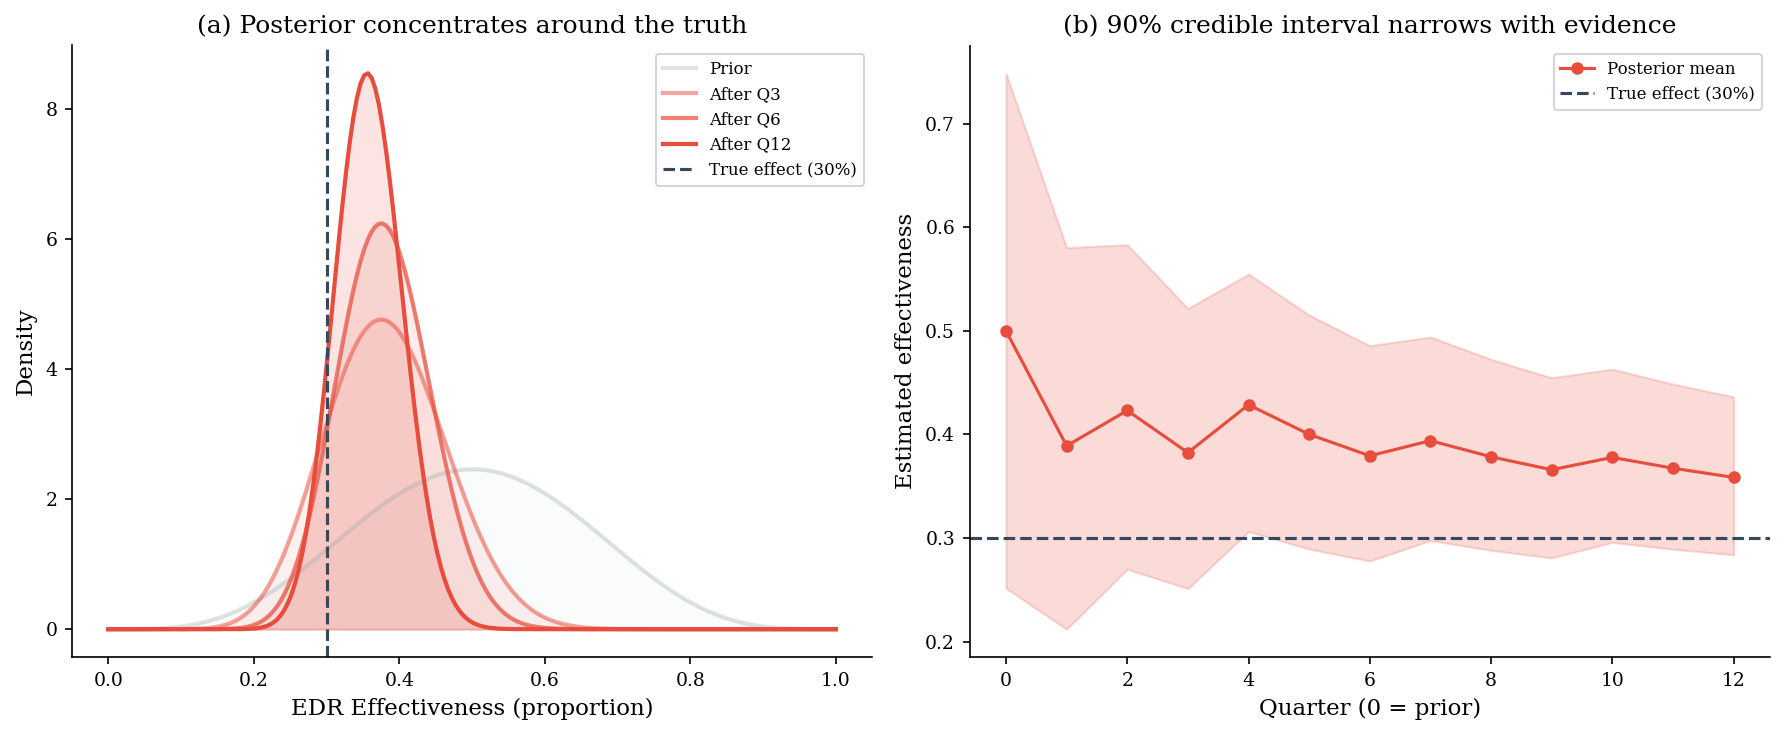

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_beta = np.linspace(0, 1, 200)

# Panel (a): posterior evolution
ax = axes[0]
steps_to_show = [0, 3, 6, 12]
alphas = [0.3, 0.5, 0.7, 1.0]
for step, alpha in zip(steps_to_show, alphas):
    a_s, b_s = history[step]
    y = beta_dist.pdf(x_beta, a_s, b_s)
    label = "Prior" if step == 0 else f"After Q{step}"
    color = LIGHT_GRAY if step == 0 else ACCENT
    ax.plot(x_beta, y, color=color, alpha=alpha, lw=2, label=label)
    ax.fill_between(x_beta, y, alpha=alpha * 0.15, color=color)

ax.axvline(true_p, color=DARK_BG, ls="--", lw=1.5, label=f"True effect ({true_p:.0%})")
ax.set_xlabel("EDR Effectiveness (proportion)")
ax.set_ylabel("Density")
ax.set_title("(a) Posterior concentrates around the truth")
ax.legend(fontsize=8)

# Panel (b): posterior mean and 90% CI over time
ax = axes[1]
quarters = range(len(history))
means = [a_h / (a_h + b_h) for a_h, b_h in history]
ci_lo = [beta_dist.ppf(0.05, a_h, b_h) for a_h, b_h in history]
ci_hi = [beta_dist.ppf(0.95, a_h, b_h) for a_h, b_h in history]

ax.fill_between(quarters, ci_lo, ci_hi, alpha=0.2, color=ACCENT)
ax.plot(quarters, means, "o-", color=ACCENT, markersize=5, label="Posterior mean")
ax.axhline(true_p, color=DARK_BG, ls="--", lw=1.5, label=f"True effect ({true_p:.0%})")
ax.set_xlabel("Quarter (0 = prior)")
ax.set_ylabel("Estimated effectiveness")
ax.set_title("(b) 90% credible interval narrows with evidence")
ax.legend(fontsize=8)
ax.set_xticks(range(0, 13, 2))

plt.tight_layout()
plt.show()

## 6. Pitfalls

- **Selection bias is the default, not the exception.** Organizations that deploy a control are systematically different from those that don't. Naive comparisons of adopters vs non-adopters confound the control's effect with everything else that differs between the groups.

- **Controls are deployed where risk is highest.** This can make effective controls look *ineffective* (or even harmful) — the opposite of the EDR example above. A firewall deployed at the most-attacked perimeter will still show more incidents than a quiet segment with no firewall. This is negative confounding, and it's at least as dangerous as the positive kind.

- **Conditioning on post-treatment variables introduces collider bias.** Analyzing only "detected" incidents, or only incidents that triggered a response, conditions on a collider. This opens spurious paths and distorts the estimated effect of the control.

- **Before-after designs confound treatment effects with time trends.** Incident rates change over time for many reasons. Without a control group, you cannot separate the effect of the intervention from the secular trend.

- **Small observational samples can be worse than no data if they create false confidence.** A single business unit's before-after comparison, treated as conclusive evidence, can anchor decisions in noise. The Bayesian approach explicitly represents uncertainty and updates incrementally — but only if you actually respect the width of the posterior.